In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

device = "cpu"

Problem 2 — Non-linear curve learning

Now the relationship is not linear.

Data
x ∈ [-2 , 2]
y = x² − 0.5x

Add noise again.

Tasks

Train your network on the dataset.

Visualize prediction curve.

Compare two models:

Model A

nn.Linear(1,1)

Model B

1 → 16 → 16 → 1
Question you must answer

Why does Model A fail but Model B succeeds?

(This is the key idea behind neural networks.)

In [2]:
# Data x ∈ [-2 , 2] y = x² − 0.5x

x=torch.arange(-2,2,0.02).unsqueeze(dim=1)

# Add noise again. noise ~ N(0,0.1)
noise = torch.randn_like(x) * 0.1

y= x**2 - 0.5*x + noise


# Split data
# # split
split = int(0.8 * len(x))
x_data_train, x_data_test = x[:split], x[split:]
y_label_train, y_label_test = y[:split], y[split:]

# move to device
x_data_train = x_data_train.to(device)
x_data_test = x_data_test.to(device)
y_label_train = y_label_train.to(device)
y_label_test = y_label_test.to(device)

In [3]:
# plt.scatter(x,y,s=4)

In [4]:
class nonLinearModel1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=1,out_features=1)
    )
  def forward(self,x:torch.tensor):
    return self.layer1(x)

In [5]:
model1 = nonLinearModel1()

In [6]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model1.parameters(),lr=0.01)

In [7]:
model1.eval()
with torch.inference_mode():
  predict_model1 = model1(x_data_test)


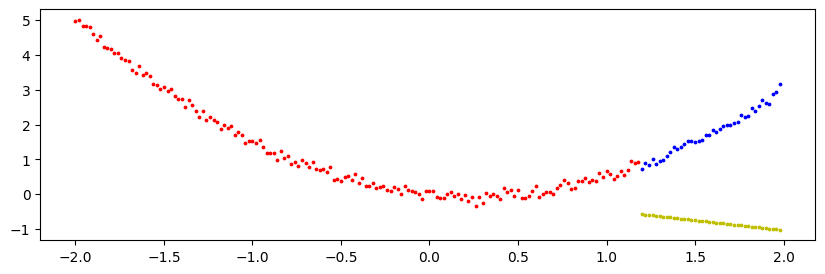

In [8]:
plt.figure(figsize=(10,3))
plt.scatter(x_data_test,y_label_test,s=3,c="b")
plt.scatter(x_data_train,y_label_train,s=3,c="r")
plt.scatter(x_data_test,predict_model1,s=3,c="y")

In [9]:
# train for loss optimize zero lobos
epoch =100
for i in range(epoch):
  model1.train()
  logit = model1(x_data_train)
  loss = loss_fn(logit,y_label_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if i % 20 == 0:
    print(f"loss: {loss}")



loss: 0.9320157170295715
loss: 0.8530956506729126
loss: 0.7961739301681519
loss: 0.7598634958267212
loss: 0.7343170642852783


In [10]:
model1.eval()
with torch.inference_mode():
  predict_model2 = model1(x_data_test)

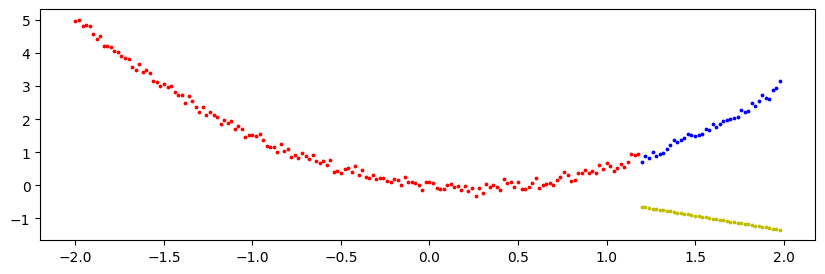

In [11]:
plt.figure(figsize=(10,3))
plt.scatter(x_data_test,y_label_test,s=3,c="b")
plt.scatter(x_data_train,y_label_train,s=3,c="r")
plt.scatter(x_data_test,predict_model2,s=3,c="y")

In [12]:
class nonLinearModel2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=1, out_features=16),
        nn.Linear(in_features=16, out_features=1)
    )
  def forward(self,x:torch.tensor):
    return self.layer1(x)

In [13]:
model2 = nonLinearModel2()

In [14]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model2.parameters(),lr=0.01)

In [15]:
epoch =1000
for i in range(epoch):
  model2.train()
  logit = model2(x_data_train)
  loss = loss_fn(logit,y_label_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if i % 200 == 0:
    print(f"loss: {loss}")


loss: 1.321315884590149
loss: 0.656530499458313
loss: 0.6561469435691833
loss: 0.656146764755249
loss: 0.6561468243598938


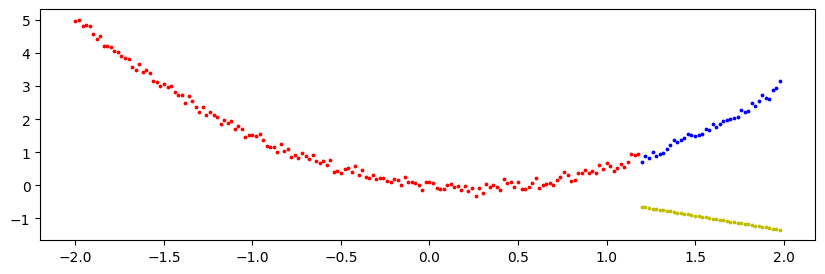

In [16]:
model2.eval()
with torch.inference_mode():
  predict_model3 = model2(x_data_test)

plt.figure(figsize=(10,3))
plt.scatter(x_data_test,y_label_test,s=3,c="b")
plt.scatter(x_data_train,y_label_train,s=3,c="r")

plt.scatter(x_data_test,predict_model2,s=3,c="y")

In [17]:
class nonLinearModel3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=1, out_features=16),
        nn.ReLU(),
        nn.Linear(in_features=16, out_features=1)
    )
  def forward(self,x:torch.tensor):
    return self.layer1(x)

In [18]:
model3 = nonLinearModel3().to(device)

In [19]:
loss_fn_model3 = nn.MSELoss()
optimizer_model3 = torch.optim.SGD(params=model3.parameters(),lr=0.01)

In [20]:
epoch = 1000
for i in range(epoch):
  model3.train()
  model3_logit = model3(x_data_train)
  loss=loss_fn_model3(model3_logit,y_label_train)

  optimizer_model3.zero_grad()
  loss.backward()
  optimizer_model3.step()



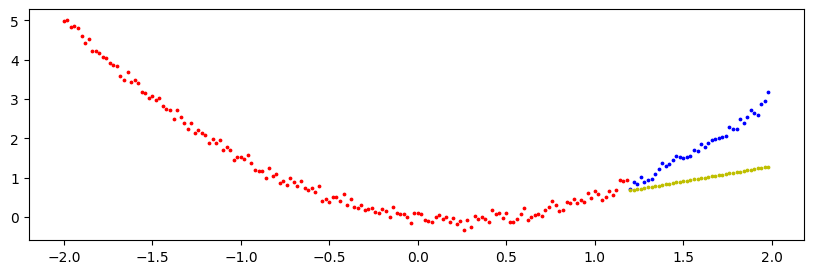

In [21]:
model3.eval()
with torch.inference_mode():
  model3_pred = model3(x_data_test)

plt.figure(figsize=(10,3))
plt.scatter(x_data_test,y_label_test,s=3,c="b")
plt.scatter(x_data_train,y_label_train,s=3,c="r")

plt.scatter(x_data_test,model3_pred,s=3,c="y")

In [22]:
# shuffle first
indices = torch.randperm(len(x))
x = x[indices]
y = y[indices]

# Split data
# # split
split = int(0.8 * len(x))
x_data_train, x_data_test = x[:split], x[split:]
y_label_train, y_label_test = y[:split], y[split:]

# move to device
x_data_train = x_data_train.to(device)
x_data_test = x_data_test.to(device)
y_label_train = y_label_train.to(device)
y_label_test = y_label_test.to(device)

In [23]:
class nonLinearModel4(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=1, out_features=16),
        nn.ReLU(),
        nn.Linear(in_features=16, out_features=1)
    )
  def forward(self,x:torch.tensor):
    return self.layer1(x)

In [24]:
model4 = nonLinearModel4().to(device)

In [25]:
loss_fn_model4 = nn.MSELoss()
optimizer_model4 = torch.optim.SGD(params=model4.parameters(),lr=0.01)

In [26]:
epoch = 1000
for i in range(epoch):
  model4.train()
  model4_logit = model4(x_data_train)
  loss=loss_fn_model4(model4_logit,y_label_train)

  optimizer_model4.zero_grad()
  loss.backward()
  optimizer_model4.step()



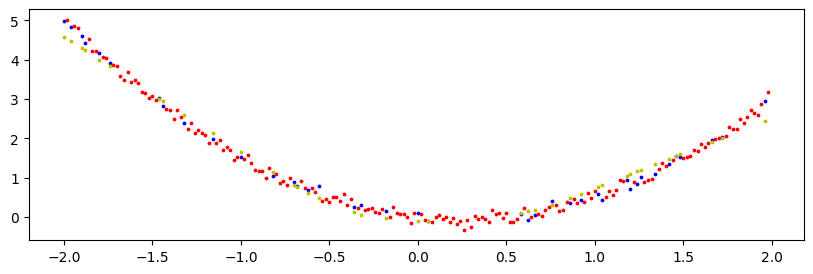

In [27]:
model4.eval()
with torch.inference_mode():
  model4_pred = model4(x_data_test)

plt.figure(figsize=(10,3))
plt.scatter(x_data_test,y_label_test,s=3,c="b")
plt.scatter(x_data_train,y_label_train,s=3,c="r")

plt.scatter(x_data_test,model4_pred,s=3,c="y")